In [18]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [19]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device: Apple MPS (M1 Max)")
else:
    device = torch.device("cpu")
    print("Device: CPU")

Device: Apple MPS (M1 Max)


In [20]:
DATA_DIR = "../data/EuroSAT_RGB"

BATCH_SIZE = 32
NUM_CLASSES = 10
SEED = 42

STAGE1_EPOCHS = 5
STAGE1_LR = 0.01

STAGE2_EPOCHS = 25
STAGE2_LR = 0.0001

In [21]:
MEAN = [0.3444, 0.3803, 0.4078]
STD = [0.2025, 0.1365, 0.1148]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

In [22]:
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
class_names = full_dataset.classes

total = len(full_dataset)
val_size = int(total * 0.2)
train_size = total - val_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size], 
    generator=generator
)

val_dataset.dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

print(f"Total images: {total}")
print(f"Training images: {train_size}")
print(f"Validation images: {val_size}")
print(f"Classes: {class_names}")

Total images: 27000
Training images: 21600
Validation images: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=False,
)

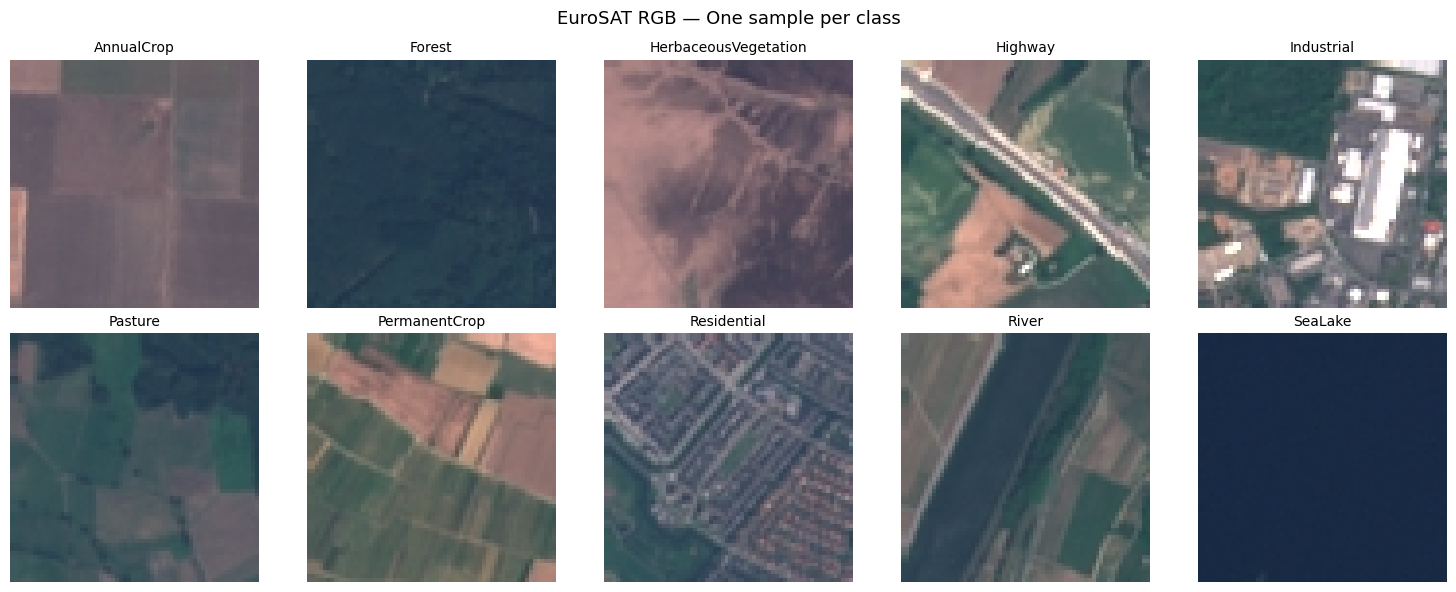

In [24]:
raw_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

shown = set()
for img, label in raw_dataset:
    if label not in shown:
        axes[label].imshow(img.permute(1, 2, 0).numpy())
        axes[label].set_title(class_names[label], fontsize=10)
        axes[label].axis('off')
        shown.add(label)
    if len(shown) == NUM_CLASSES:
        break

plt.suptitle('EuroSAT RGB — One sample per class', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params: 23,528,522
Trainable params: 20,490


In [26]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * images.size(0)
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
    return loss_sum / total, 100.0 * correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * images.size(0)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    return loss_sum / total, 100.0 * correct / total

In [27]:
def run_stage(model, train_loader, val_loader, epochs, lr, stage_name):
    print(f'\n{"-"*50}')
    print(f'{stage_name} — {epochs} epochs, lr={lr}')
    print(f'{"-"*50}')

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_acc = 0.0
    history  = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = val_epoch(model, val_loader, criterion)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f'Epoch [{epoch:02d}/{epochs}] '
              f'Train: {train_acc:.2f}% | '
              f'Val: {val_acc:.2f}%')

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), '../results/models/resnet50_eurosat.pth')
            print(f'  --> Best model saved ({best_acc:.2f}%)')

    return history, best_acc

In [28]:
import os

In [29]:
os.makedirs('../results/models', exist_ok=True)

history1, best1 = run_stage(
    model, train_loader, val_loader,
    epochs=STAGE1_EPOCHS,
    lr=STAGE1_LR,
    stage_name='Stage 1 — Last layer only'
)


--------------------------------------------------
Stage 1 — Last layer only — 5 epochs, lr=0.01
--------------------------------------------------
Epoch [01/5] Train: 78.24% | Val: 85.93%
  --> Best model saved (85.93%)
Epoch [02/5] Train: 83.89% | Val: 90.56%
  --> Best model saved (90.56%)
Epoch [03/5] Train: 85.39% | Val: 88.00%
Epoch [04/5] Train: 86.00% | Val: 90.74%
  --> Best model saved (90.74%)
Epoch [05/5] Train: 87.13% | Val: 89.57%


In [30]:
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'All layers unfrozen. Trainable params: {trainable:,}')

history2, best2 = run_stage(
    model, train_loader, val_loader,
    epochs=STAGE2_EPOCHS,
    lr=STAGE2_LR,
    stage_name='Stage 2 — Full network fine-tuning'
)

All layers unfrozen. Trainable params: 23,528,522

--------------------------------------------------
Stage 2 — Full network fine-tuning — 25 epochs, lr=0.0001
--------------------------------------------------
Epoch [01/25] Train: 92.94% | Val: 97.78%
  --> Best model saved (97.78%)
Epoch [02/25] Train: 96.58% | Val: 97.48%
Epoch [03/25] Train: 97.10% | Val: 97.17%
Epoch [04/25] Train: 97.07% | Val: 97.89%
  --> Best model saved (97.89%)
Epoch [05/25] Train: 97.31% | Val: 96.98%
Epoch [06/25] Train: 97.67% | Val: 97.81%
Epoch [07/25] Train: 97.58% | Val: 97.96%
  --> Best model saved (97.96%)
Epoch [08/25] Train: 97.80% | Val: 97.09%
Epoch [09/25] Train: 98.15% | Val: 98.39%
  --> Best model saved (98.39%)
Epoch [10/25] Train: 98.26% | Val: 97.78%
Epoch [11/25] Train: 98.17% | Val: 98.28%
Epoch [12/25] Train: 98.40% | Val: 98.20%
Epoch [13/25] Train: 98.48% | Val: 97.83%
Epoch [14/25] Train: 98.62% | Val: 98.07%
Epoch [15/25] Train: 98.67% | Val: 98.31%
Epoch [16/25] Train: 98.53% | V

In [33]:
os.makedirs('../results/figures', exist_ok=True)

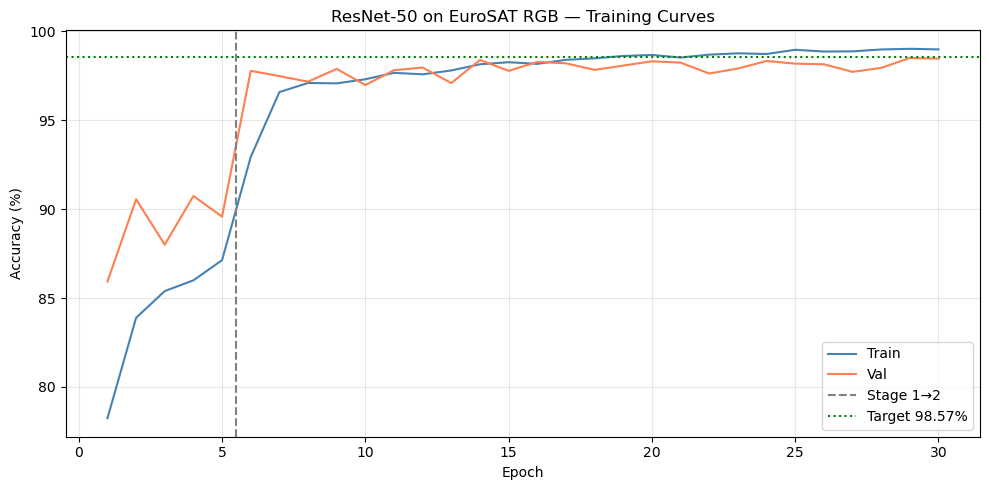

In [34]:
all_train_acc = history1['train_acc'] + history2['train_acc']
all_val_acc = history1['val_acc'] + history2['val_acc']
epochs_total = list(range(1, len(all_val_acc) + 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs_total, all_train_acc, label='Train', color='steelblue')
plt.plot(epochs_total, all_val_acc, label='Val', color='coral')
plt.axvline(x=STAGE1_EPOCHS + 0.5, color='gray', linestyle='--', label='Stage 1→2')
plt.axhline(y=98.57, color='green', linestyle=':', label='Target 98.57%')
plt.title('ResNet-50 on EuroSAT RGB — Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/training_curves.png', dpi=150)
plt.show()

Final Accuracy: 98.50%
Target: 98.57%
Difference: -0.07%

                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.99      0.98       631
              Forest       0.99      0.99      0.99       582
HerbaceousVegetation       0.98      0.99      0.98       612
             Highway       0.98      0.99      0.99       525
          Industrial       0.99      0.98      0.99       484
             Pasture       0.97      0.98      0.98       396
       PermanentCrop       0.98      0.96      0.97       506
         Residential       0.99      1.00      0.99       606
               River       0.99      0.98      0.98       497
             SeaLake       1.00      0.99      0.99       561

            accuracy                           0.98      5400
           macro avg       0.98      0.98      0.98      5400
        weighted avg       0.99      0.98      0.98      5400



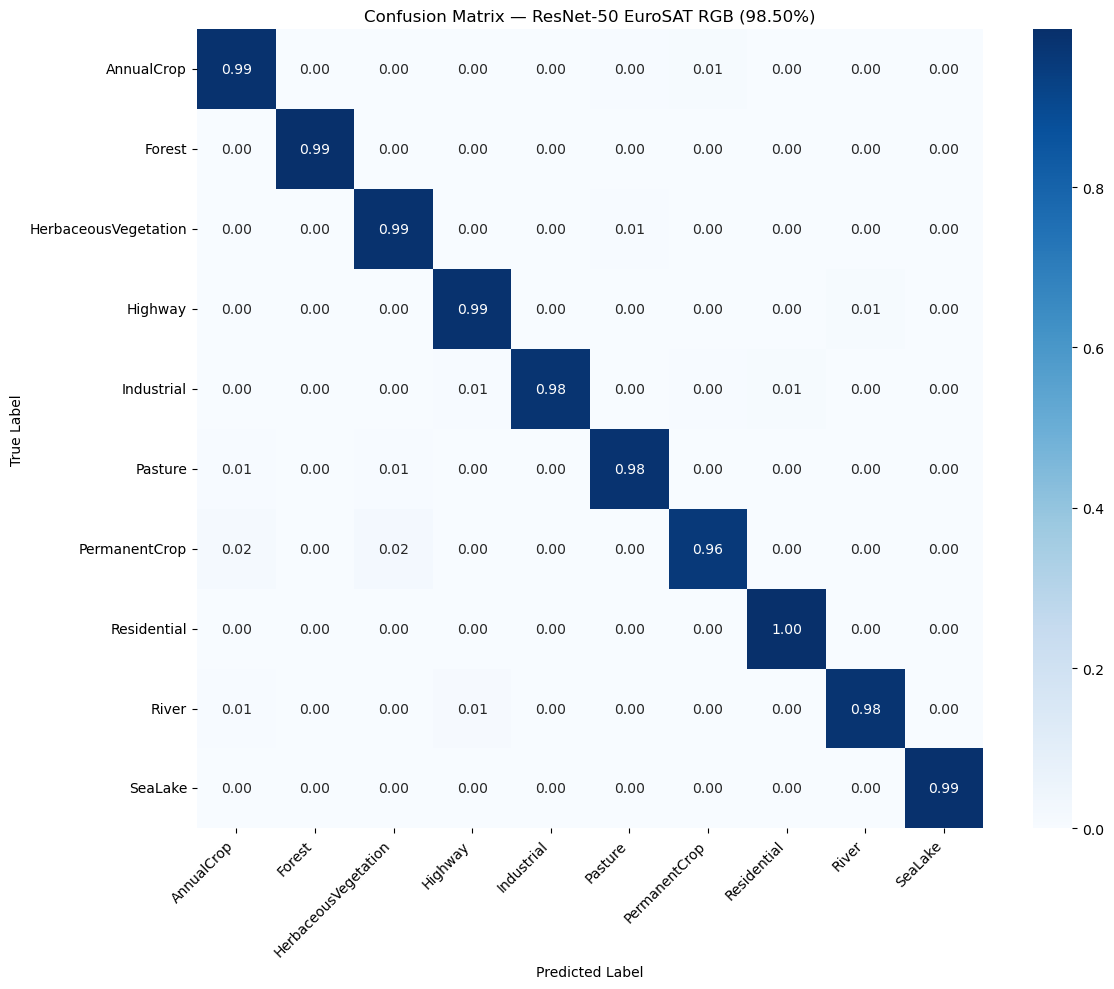

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.load_state_dict(torch.load('../results/models/resnet50_eurosat.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
print(f'Final Accuracy: {accuracy:.2f}%')
print('Target: 98.57%')
print(f'Difference: {accuracy - 98.57:+.2f}%\n')
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — ResNet-50 EuroSAT RGB ({accuracy:.2f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix.png', dpi=150)
plt.show()